In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Vérification CPU/GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device utilisé : {device}")
print(f"PyTorch version : {torch.__version__}")

 Device utilisé : cpu
PyTorch version : 2.11.0+cpu


In [3]:
df = pd.read_csv("../data/synthetic/vitals_history.csv")

print(f" {len(df)} mesures chargées")
print(f"Patients : {df['patient_id'].nunique()}")
print(f"Paramètres disponibles : {[c for c in df.columns if c not in ['patient_id','date','day']]}")

# On cible la prédiction de la tension systolique
# (paramètre le plus critique pour les patients HTA)
TARGET_PARAM = "systolic_bp"
SEQUENCE_LENGTH = 14  # 14 jours d'historique pour prédire J+1
FORECAST_HORIZON = 1  # On prédit 1 jour en avance

# Normalisation par patient (chaque patient a sa propre échelle)
scalers = {}
df_scaled = df.copy()

for patient_id in df["patient_id"].unique():
    mask = df["patient_id"] == patient_id
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_scaled.loc[mask, TARGET_PARAM] = scaler.fit_transform(
        df.loc[mask, TARGET_PARAM].values.reshape(-1, 1)
    ).flatten()
    scalers[patient_id] = scaler

print(f"\n Normalisation effectuée pour {len(scalers)} patients")
print(f"Séquence d'entrée : {SEQUENCE_LENGTH} jours → prédiction J+{FORECAST_HORIZON}")

 1800 mesures chargées
Patients : 20
Paramètres disponibles : ['systolic_bp', 'diastolic_bp', 'heart_rate', 'glucose', 'weight', 'temperature']

 Normalisation effectuée pour 20 patients
Séquence d'entrée : 14 jours → prédiction J+1


In [4]:
class VitalsDataset(Dataset):
    """
    Dataset PyTorch pour séries temporelles de paramètres vitaux.
    Chaque sample = séquence de SEQUENCE_LENGTH valeurs → valeur suivante.
    C'est le principe du "sliding window" (fenêtre glissante).
    """
    def __init__(self, dataframe: pd.DataFrame, seq_len: int, target_col: str):
        self.sequences = []
        self.targets = []

        for patient_id in dataframe["patient_id"].unique():
            patient_data = dataframe[dataframe["patient_id"] == patient_id].sort_values("day")
            values = patient_data[target_col].values.astype(np.float32)

            # Création des fenêtres glissantes
            for i in range(len(values) - seq_len):
                seq = values[i:i + seq_len]
                target = values[i + seq_len]
                self.sequences.append(seq)
                self.targets.append(target)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx]).unsqueeze(-1)  # (seq_len, 1)
        y = torch.tensor(self.targets[idx]).unsqueeze(-1)    # (1,)
        return x, y

# Split temporel : 80% train, 20% test
all_patients = df_scaled["patient_id"].unique()
n_train = int(len(all_patients) * 0.8)
train_patients = all_patients[:n_train]
test_patients = all_patients[n_train:]

train_df = df_scaled[df_scaled["patient_id"].isin(train_patients)]
test_df = df_scaled[df_scaled["patient_id"].isin(test_patients)]

train_dataset = VitalsDataset(train_df, SEQUENCE_LENGTH, TARGET_PARAM)
test_dataset = VitalsDataset(test_df, SEQUENCE_LENGTH, TARGET_PARAM)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f" Dataset créé")
print(f"Train : {len(train_dataset)} séquences")
print(f"Test  : {len(test_dataset)} séquences")

# Vérification d'un batch
x_sample, y_sample = next(iter(train_loader))
print(f"\nShape X (batch) : {x_sample.shape}  → (batch, seq_len, features)")
print(f"Shape y (batch) : {y_sample.shape}  → (batch, 1)")

 Dataset créé
Train : 1216 séquences
Test  : 304 séquences

Shape X (batch) : torch.Size([32, 14, 1])  → (batch, seq_len, features)
Shape y (batch) : torch.Size([32, 1])  → (batch, 1)


In [5]:
class LightLSTM(nn.Module):
    """
    LSTM léger pour prédiction de séries temporelles médicales.
    Architecture volontairement simple pour tourner sur CPU.
    
    Analogie : le LSTM lit les mesures passées comme un médecin 
    lit un carnet de santé, et prédit la prochaine valeur.
    """
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.2):
        super(LightLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Couche LSTM : lit la séquence temporelle
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,      # (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0
        )

        # Couche de normalisation pour stabiliser l'entraînement
        self.layer_norm = nn.LayerNorm(hidden_size)

        # Tête de prédiction : LSTM output → valeur scalaire
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Initialisation des états cachés à zéro
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Passage dans le LSTM
        out, _ = self.lstm(x, (h0, c0))

        # On prend uniquement la sortie du dernier pas de temps
        out = self.layer_norm(out[:, -1, :])

        # Prédiction finale
        return self.fc(out)


# Instanciation et résumé du modèle
model = LightLSTM().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f" Modèle LSTM créé")
print(f"Paramètres totaux : {total_params:,}")
print(f"\nArchitecture :")
print(model)

 Modèle LSTM créé
Paramètres totaux : 13,537

Architecture :
LightLSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [7]:
# Hyperparamètres
EPOCHS = 30
LEARNING_RATE = 0.001
PATIENCE = 5  # Early stopping

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5  # ← verbose=True supprimé
)

train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0

print(f"Entraînement sur {EPOCHS} epochs (device: {device})\n")

for epoch in range(EPOCHS):
    # --- Phase d'entraînement ---
    model.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    # --- Phase de validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            val_loss += criterion(predictions, y_batch).item()

    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "../ml_models/timeseries/best_lstm.pth")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping déclenché à l'epoch {epoch+1}")
        break

print(f"\nMeilleur Val Loss : {best_val_loss:.6f}")

Entraînement sur 30 epochs (device: cpu)

Epoch   5/30 | Train Loss: 0.051559 | Val Loss: 0.039565
Epoch  10/30 | Train Loss: 0.048488 | Val Loss: 0.043787
Epoch  15/30 | Train Loss: 0.043398 | Val Loss: 0.036818
Epoch  20/30 | Train Loss: 0.045219 | Val Loss: 0.035996
Epoch  25/30 | Train Loss: 0.042482 | Val Loss: 0.037138

Early stopping déclenché à l'epoch 25

Meilleur Val Loss : 0.035996


 Métriques sur données test (dénormalisées) :
MAE  : 5.06 mmHg
RMSE : 6.38 mmHg


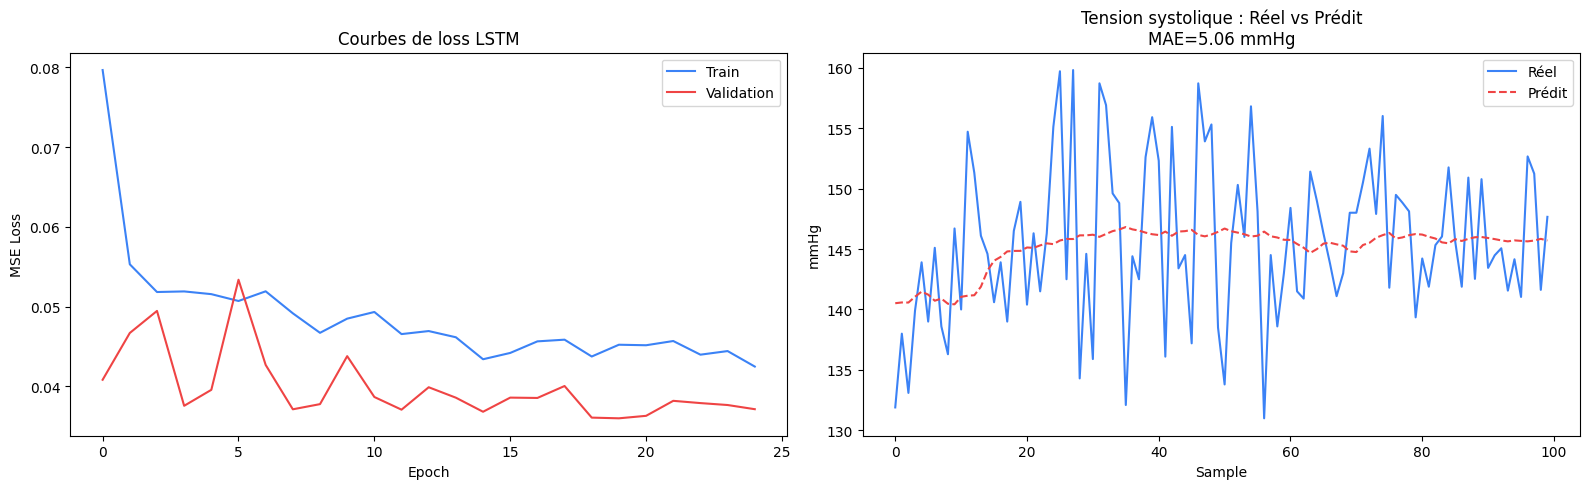

In [8]:
# Chargement du meilleur modèle
model.load_state_dict(torch.load("../ml_models/timeseries/best_lstm.pth", map_location=device))
model.eval()

# Collecte des prédictions
all_preds, all_targets = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch.to(device)).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_targets.extend(y_batch.numpy().flatten())

# Dénormalisation avec le scaler du premier patient test
first_test_patient = test_patients[0]
scaler = scalers[first_test_patient]

preds_real = scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
targets_real = scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()

mae = mean_absolute_error(targets_real, preds_real)
rmse = np.sqrt(mean_squared_error(targets_real, preds_real))

print(f" Métriques sur données test (dénormalisées) :")
print(f"MAE  : {mae:.2f} mmHg")
print(f"RMSE : {rmse:.2f} mmHg")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses, label="Train", color="#3b82f6")
axes[0].plot(val_losses, label="Validation", color="#ef4444")
axes[0].set_title("Courbes de loss LSTM")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

n_display = min(100, len(preds_real))
axes[1].plot(targets_real[:n_display], label="Réel", color="#3b82f6", linewidth=1.5)
axes[1].plot(preds_real[:n_display], label="Prédit", color="#ef4444",
             linewidth=1.5, linestyle="--")
axes[1].set_title(f"Tension systolique : Réel vs Prédit\nMAE={mae:.2f} mmHg")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("mmHg")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/lstm_evaluation.png", dpi=150)
plt.show()

In [ ]:
os.makedirs("../ml_models/timeseries", exist_ok=True)

# Sauvegarde du scaler (nécessaire pour dénormaliser en inférence)
with open("../ml_models/timeseries/scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)

# Sauvegarde de la config du modèle
import json
model_config = {
    "input_size": 1,
    "hidden_size": 32,
    "num_layers": 2,
    "dropout": 0.2,
    "sequence_length": SEQUENCE_LENGTH,
    "target_param": TARGET_PARAM
}
with open("../ml_models/timeseries/model_config.json", "w") as f:
    json.dump(model_config, f)

print(" Modèle LSTM sauvegardé :")
print("  → ml_models/timeseries/best_lstm.pth")
print("  → ml_models/timeseries/scalers.pkl")
print("  → ml_models/timeseries/model_config.json")